In [39]:
import numpy as np
import BLEanalysis.angleinference as AngleInference
np.set_printoptions(precision=2,suppress=True)
import matplotlib.pyplot as plt
from BLEanalysis.signals import Signals
import pyproj
from BLEanalysis.angleinference import AnglesUsePeaks, AnglesUsePatternMeans, normalise_logs_to_ps
from BLEanalysis.pathinference import Path_ProbabilityDensitiesToBee, Path_VectorsToBee
from BLEanalysis.kernels import ExponentiatedQuadraticKernel
from matplotlib.pyplot import figure
from BLEanalysis import confidence_ellipse
from BLEanalysis.signals import Signals
from BLEanalysis.angleinference import AnglesUsePeaks, AnglesUseRejectionSampling, AnglesUsePatternMeans, normalise_logs_to_ps
from BLEanalysis.pathinference import Path_ProbabilityDensitiesToBee, Path_VectorsToBee
from BLEanalysis.kernels import ExponentiatedQuadraticKernel,EQIntegralKernel
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from jax.random import normal
import jax
from jax.random import multivariate_normal as mvn
from BLEanalysis.angleinference import AnglesUsePatternMeans, normalise_logs_to_ps
from scipy.stats import circmean
import pickle

Normalizing the transmitter positions (TODO: Do this in a method in angleinference object):

Text(-1.541619, 53.356308, 'Copse of Trees')

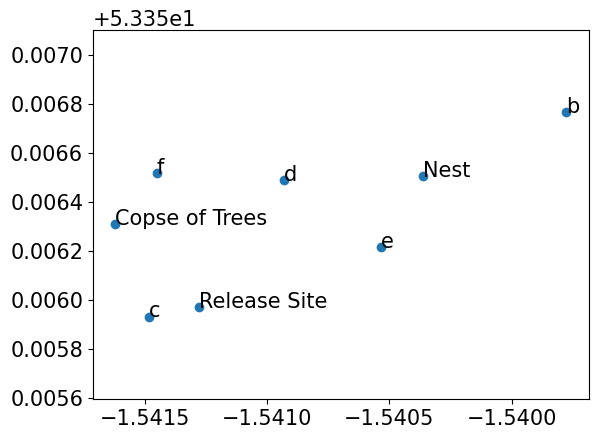

In [40]:
# coords for transmitters b,c,d,e,f, release site, nest, copse of trees
xx = [-1.539777,-1.541483,-1.540932,-1.540533,-1.541451,-1.541279, -1.540364,-1.541619] # x axis
yy = [53.356765,53.355931,53.356487,53.356215,53.356516, 53.355968, 53.356505, 53.356308] # y axis
plt.axis("equal")
plt.scatter(xx,yy)
plt.text(xx[0],yy[0],'b')
plt.text(xx[1],yy[1],'c')
plt.text(xx[2],yy[2],'d')
plt.text(xx[3],yy[3],'e')
plt.text(xx[4],yy[4],'f')
plt.text(xx[5],yy[5],'Release Site')
plt.text(xx[6],yy[6],'Nest')
plt.text(xx[7],yy[7],'Copse of Trees')

Load data, add transmitter locations and shift times:

Packets used to calibrate time: (take a zero point, minus real time difference between time that zero point was taken and packet, use that time difference to move packet time to zero point time, subtract to get offset)

[2025-08-19 12:21:40.244] RSSI: -95 [da:2a:91:2a:11:8c] 2789674 + 112679 = 2902353. 2468288 - 2902353 = - 434065

[2025-08-19 12:21:40.531] RSSI: -97 [da:25:6e:fd:07:7e] 2453245 + 112392 = 2565637. 2468288 - 2565637 = -97349

[2025-08-19 12:23:32.923] RSSI: -96 [da:25:a9:c0:07:2b] 2468288 (zero point)

[2025-08-19 12:23:33.038] RSSI: -94 [da:29:69:82:00:7d] 2713986 - 1060 = 2712926. 2468288 - 2712926 = -244638

[2025-08-19 12:22:35.435] RSSI: -96 [da:29:f8:4f:0e:7f] 2750543 + 57488 = 2808031. 2468288 - 2808031 = -339743



In [41]:
testdata = Signals("../../tagtest2.txt",['b','e','f'],filetype='pcap',angleOffset=0)

Standardising angles and times (shifting by 0.00 degrees)


Transmitter       Number of records
        b                   34
        e                   74
        f                   66


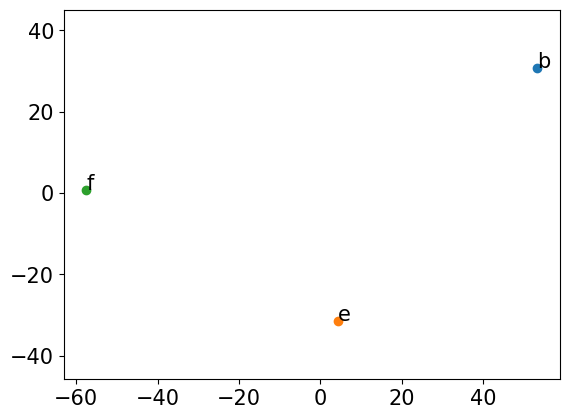

In [42]:

testdata.configureTransmitter('b',0,0,transmitterLat = yy[0], transmitterLon = xx[0])
#testdata.configureTransmitter('c',434065,0,transmitterLat = yy[1], transmitterLon = xx[1])
#testdata.configureTransmitter('d',244638,0,transmitterLat = yy[2], transmitterLon = xx[2])
testdata.configureTransmitter('e',97349,0,transmitterLat = yy[3], transmitterLon = xx[3])
testdata.configureTransmitter('f',339743,0,transmitterLat = yy[4], transmitterLon = xx[4])
testdata.noramliseTransmitterLocs()
testdata.summarise()

Use peaks to get angle (just as a quick method, do something more robust later - the data is super noisy D:)

In [43]:
obs = []
obstimes = []

# Get packet bursts from data
burst, time = testdata.parseBursts(burstInterval=2000)
angles = AnglesUsePeaks(windowLength=3)

# For each burst
for b in range(len(burst)):
    # Infer an angle
    prediction = angles.infer(burst[b]['rssis'], burst[b]['angles'])
    # If a peak was found
    if not (np.isnan(prediction)):
        # Add observation in form [transmitter_x, transmitter_y, vector_x, vector_y]
        obs.append([burst[b]['transmitter_position'][0][1], burst[b]['transmitter_position'][0][0], np.sin(prediction), np.cos(prediction)])
        # Add time of observation
        obstimes.append(time[b])

# Scale down times and standardise times such that they start at zero
time_min = np.min(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_min) / 10000

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


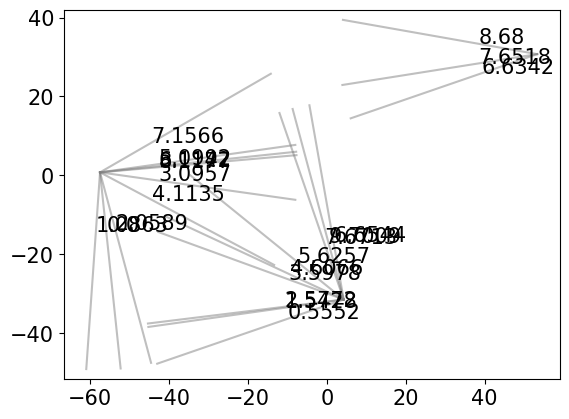

In [44]:
plt.axis('equal')
for (observation, time) in zip(obs, obstimes):
    plt.plot([observation[0], observation[0]+observation[2]*50],[observation[1],observation[1]+observation[3]*50],color='grey',alpha=0.5)
    plt.text(observation[0]+observation[2]*15, observation[1]+observation[3]*15, time)

In [74]:
obstimes = [9,8,7,0,1,2,3,4,5,6,7,8,0,1,2,3,4,5,6,7,8] # Just using burst number right now, technically on holiday so haven't done the time conversion yet :)
k = EQIntegralKernel(2,10)
path = Path_VectorsToBee(np.array(obstimes),np.array(obs),k,10,0.1, margin = np.max(obstimes) * 0.1, jitter = 0.1)
path.run(200,learning_rate=1, just_optimise_means = False)


Optimising mean...
iteration    0: 1105960.5
iteration   50:  294754.9
iteration  100:  280231.1
iteration  150:  273730.2
Optimising mean and covariance...
iteration    0:  262231.8
iteration   50:  233491.1
iteration  100:  230428.0
iteration  150:  230300.0


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


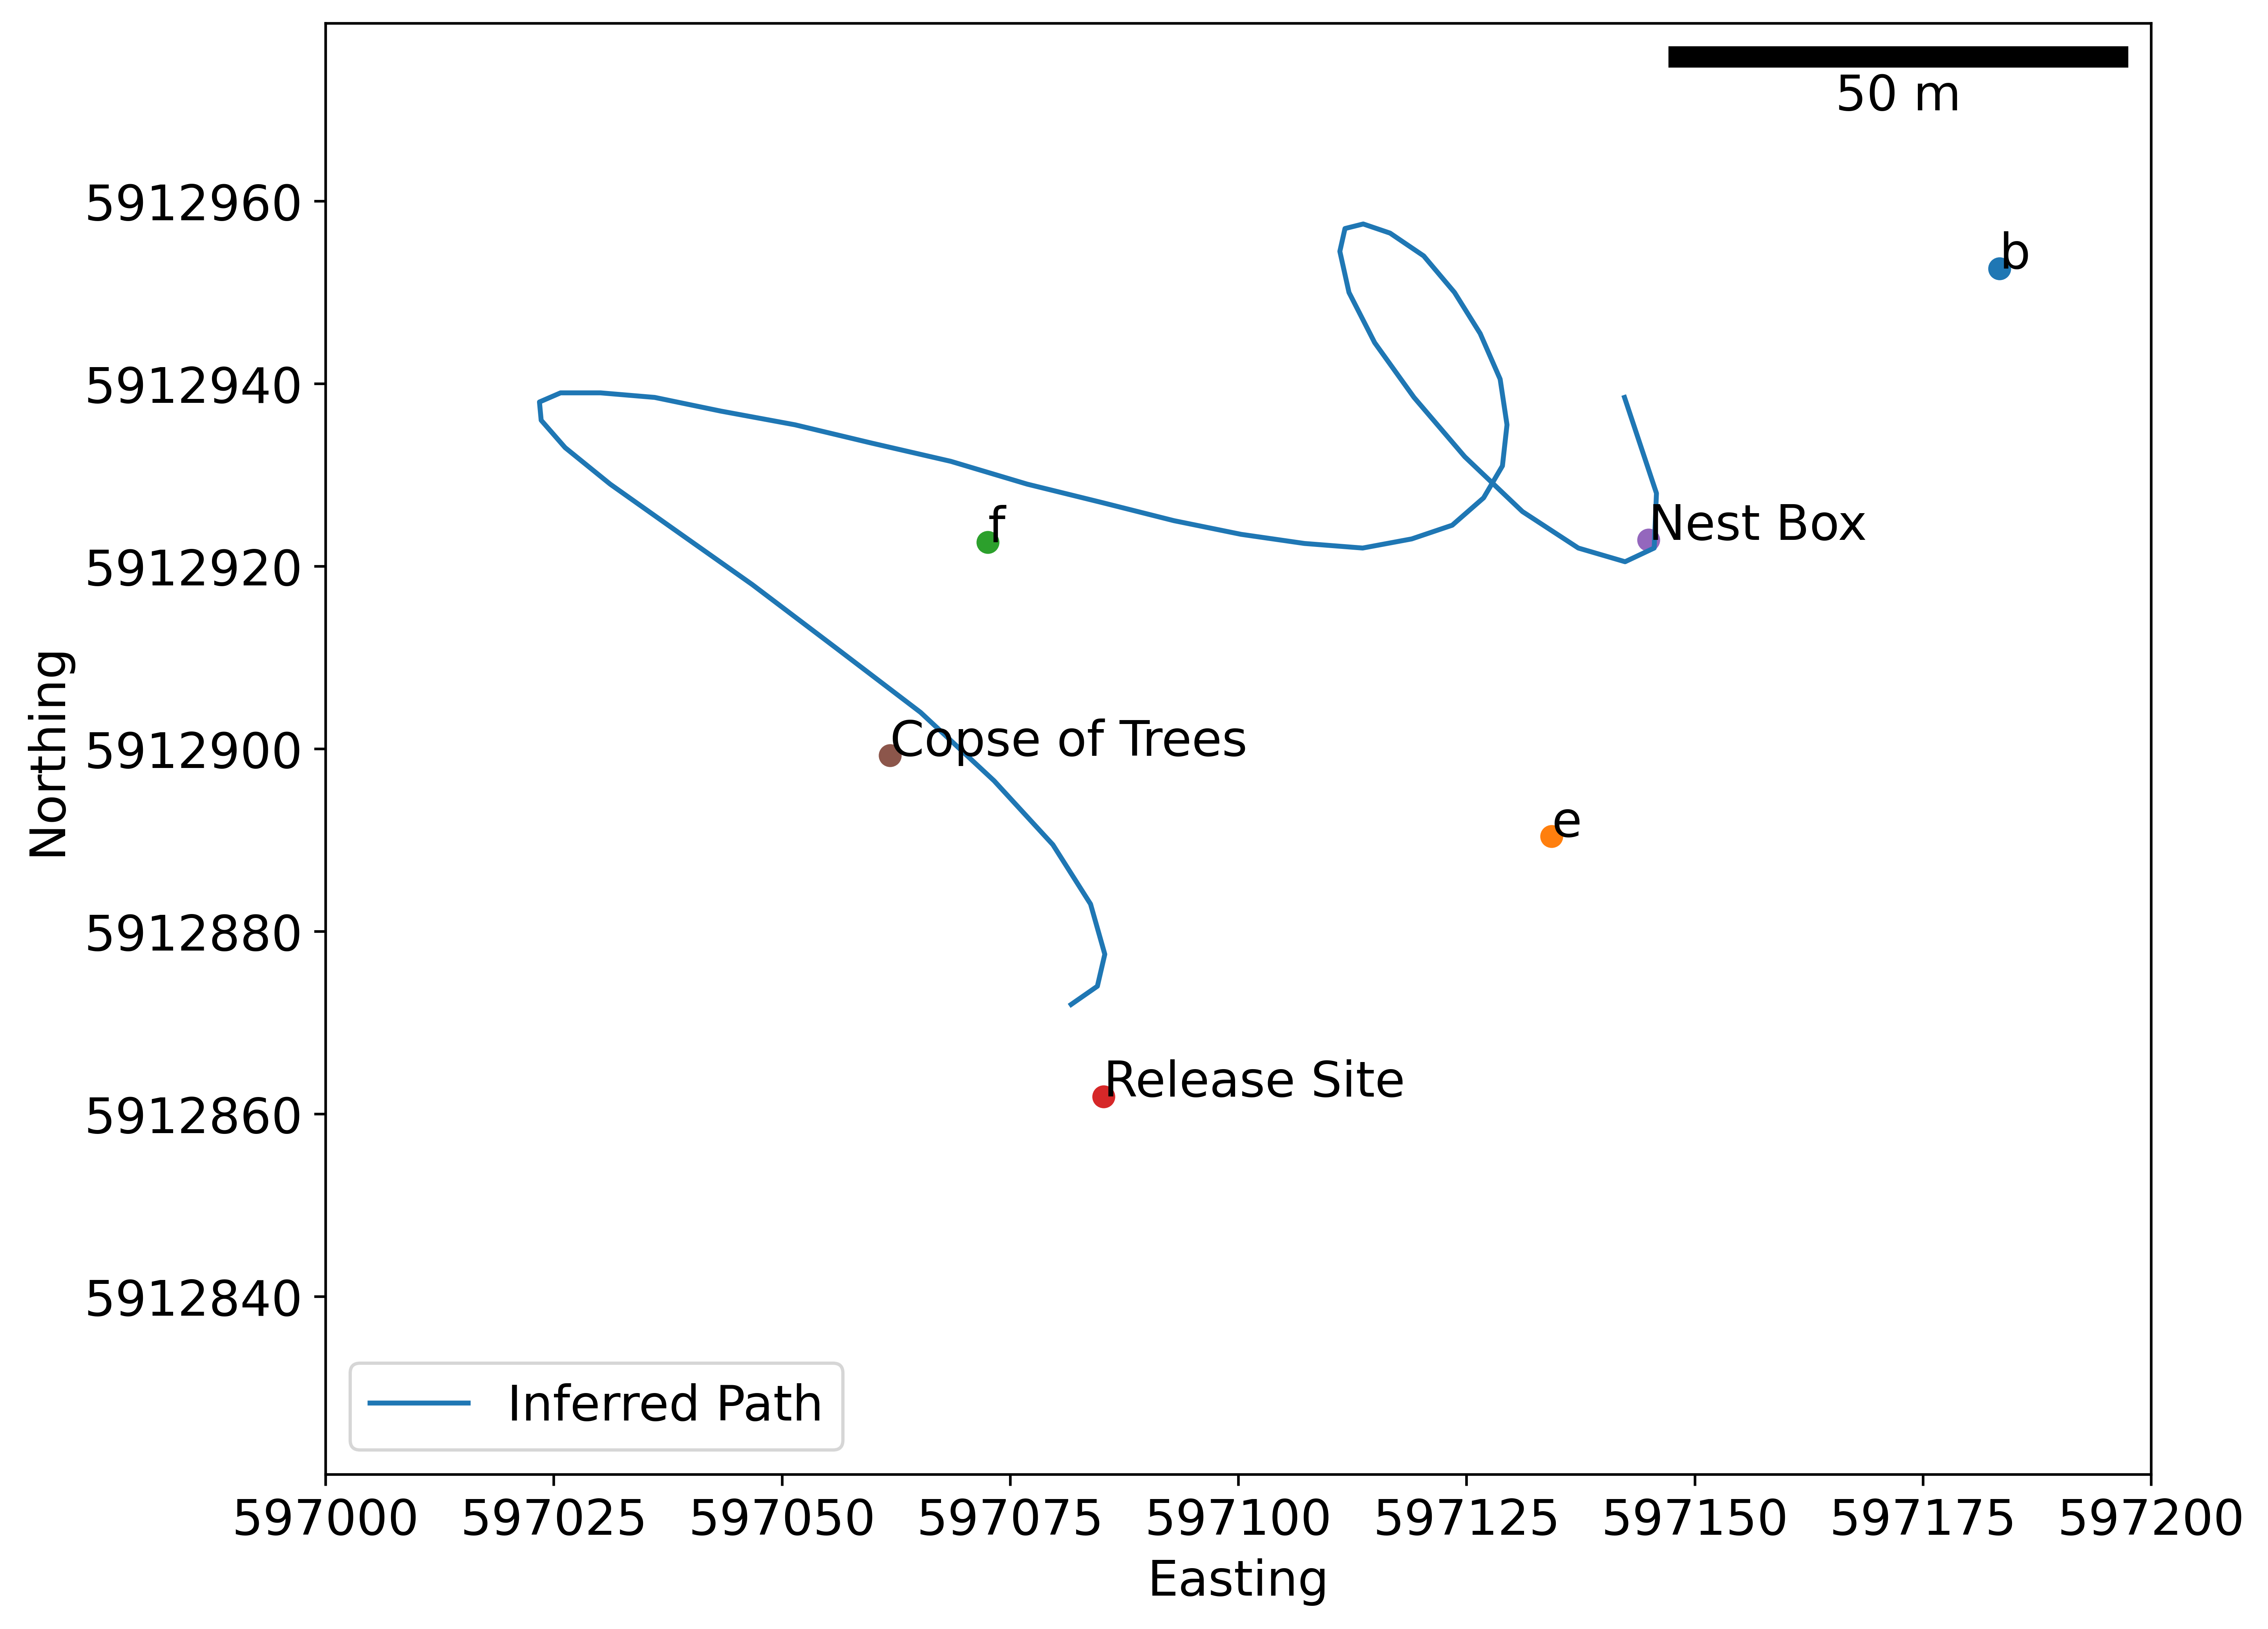

In [75]:
plt.figure(figsize=(10, 8), dpi=600)
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 15}

mpl.rc('font', **font)
path.plot(startTime = 1.5, endTime = 9, 
          transmitters = testdata.transmitterLocations, 
          ellipseInterval = 0, timeMultiplier = 10000,
          coordScaleFactor = testdata.coordNormalisationFactor)
#plt.scatter(xx[6],yy[6],'Nest')
P = pyproj.Proj(proj='utm', zone=30, ellps='WGS84', preserve_units=True)
plt.scatter(P(xx[5],yy[5])[0],P(xx[5],yy[5])[1])
plt.text(P(xx[5],yy[5])[0],P(xx[5],yy[5])[1], "Release Site")
plt.scatter(P(xx[6],yy[6])[0],P(xx[6],yy[6])[1])
plt.text(P(xx[6],yy[6])[0],P(xx[6],yy[6])[1], "Nest Box")
plt.scatter(P(xx[7],yy[7])[0],P(xx[7],yy[7])[1])
plt.text(P(xx[7],yy[7])[0],P(xx[7],yy[7])[1], "Copse of Trees")
plt.xlim(597000,597200)
plt.ylim(5912800,5913000)
plt.savefig("plot1.png", dpi=600)

In [ ]:
obs = []
obstimes = []
burst, time = testdata.parseBursts(burstInterval=0)
anglesPattern = AnglesUsePatternMeans(noisevar=6**2)

for b in range(len(burst)):
    logps,_,_,_ = anglesPattern.infer(burst[b]['rssis'],burst[b]['angles'])
    ps = normalise_logs_to_ps(logps)
    prediction = np.argmax(ps)
    if not (np.isnan(prediction)):
        obstimes.append(time[b])
        obs.append(burst[b])
        
# Scale down times and standardise times such that they start at zero
time_min = np.min(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_min) / 10000

In [10]:
# NOISE SCALE, INDUCING POINTS TODO : standardize order
k = EQIntegralKernel(1,5)
path = Path_ProbabilityDensitiesToBee(np.array(obstimes),obs,k,0.25,10, margin = np.max(obstimes) * 0.1, jitter = 0.1)

path.run(200,learning_rate=1, just_optimise_means = False)

Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:  381150.5
iteration   50:  227537.4
iteration  100:  221648.0
iteration  150:  221410.8
Optimising mean and covariance...
iteration    0:  246495.6
iteration   50:  202664.0
iteration  100:  198404.1
iteration  150:  188567.9


Text(597144.918852641, 5912922.906910007, 'Nest Box')

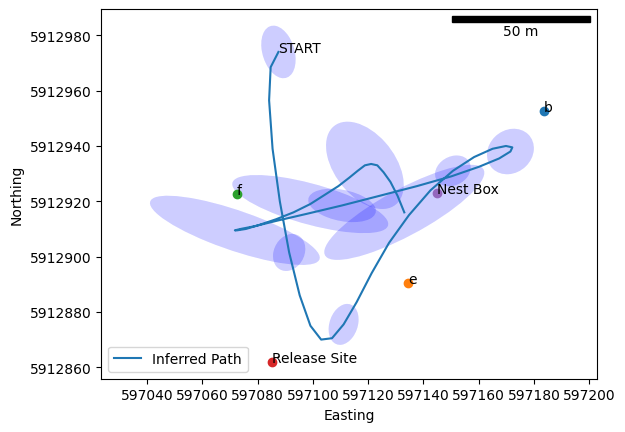

In [11]:
path.plot(startTime = 0.75, endTime = 8.5, 
          transmitters = testdata.transmitterLocations, 
          ellipseInterval = 10, timeMultiplier = 10000,
          coordScaleFactor = testdata.coordNormalisationFactor)
#plt.scatter(xx[6],yy[6],'Nest')
P = pyproj.Proj(proj='utm', zone=30, ellps='WGS84', preserve_units=True)
plt.scatter(P(xx[5],yy[5])[0],P(xx[5],yy[5])[1])
plt.text(P(xx[5],yy[5])[0],P(xx[5],yy[5])[1], "Release Site")
plt.scatter(P(xx[6],yy[6])[0],P(xx[6],yy[6])[1])
plt.text(P(xx[6],yy[6])[0],P(xx[6],yy[6])[1], "Nest Box")